In [78]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

# Dispersión de velocidades forma analítica y numérica

Se tiene que la dispersión de velocidades es: $$\sigma^2(r) = \frac{1}{\rho(r)}\int_r^\infty \rho(r')\frac{GM(<r')}{r'^2}\mathrm{d}r'$$ donde se toma: $\frac{\mathrm{d}\Phi}{\mathrm{d}r} = \frac{GM(<r)}{r^2}$ y $M(<r)$ es la masa encerrada en un radio $r$. 

Por otro lado se toma la densidad $\rho(r)$ como la densidad volumétrica dada por King (1962): $$\rho(r) = \frac{k}{\pi r_c \left[1+(r_t/r_c)^2 \right]^{\frac{3}{2}}} \frac{1}{w^2}\left[\frac{1}{w}\cos^{-1}w - (1-w^2)^\frac{1}{2}\right]$$ donde: $$w = \left[\frac{1+(r/r_c)^2}{1+(r_t/r_c)^2}\right]^\frac{1}{2}$$ y $k$ es una constante de normalización.

El objetivo de este notebook es hallar la dispersión de velocidades para un respectivo cúmulo usando los datos $X$, $Y$, $Z$, hallados anteriormente usando el modelo de King y comparar el resultado con la dispersión de velocidades analítica usando el mismo modelo.

---

Se importan tablas.

In [79]:
clusters = pd.read_csv('../data/processed/clusters.csv')
members = pd.read_csv('../data/processed/members_with_estimated_masses.csv')

### Funciones necesarias

#### Función que calcula las distancias angulares

In [80]:
def angular_distances(ra0, dec0, ras, decs):
    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)
    ras = np.radians(ras)
    decs = np.radians(decs)

    delta_ra = ras - ra0
    delta_dec = decs - dec0

    a = np.sin(delta_dec / 2)**2 + np.cos(dec0) * np.cos(decs) * np.sin(delta_ra / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c

#### Función que proyecta al plano tangente

In [81]:
def tangent_plane_projection(ras, decs, ra0, dec0, d0):
    ras = np.radians(ras)
    decs = np.radians(decs)

    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)

    delta_ras = ras - ra0

    den = (np.sin(dec0) * np.sin(decs) + 
           np.cos(dec0) * np.cos(decs) * np.cos(delta_ras))
    
    xi = (np.cos(decs) * np.sin(delta_ras)) / den

    eta = (np.cos(dec0) * np.sin(decs) - 
           np.sin(dec0) * np.cos(decs) * np.cos(delta_ras)) / den
    
    X = xi * d0
    Y = eta * d0

    return X, Y

#### Función de densidad proyectada (King 1962)

In [82]:
def sigma(r, rc, rt, k):
    term1 = 1 / (1 + (r / rc)**2)**0.5
    term2 = 1 / (1 + (rt / rc)**2)**0.5

    sigma = k * (term1 - term2)**2
    sigma[r > rt] = 0
    
    return sigma

#### Función de densidad volumétrica (King 1962)

In [83]:
def rho(r, rc, rt, k):
  values = np.zeros_like(r, dtype=float)

  mask = r < rt
  r_valid = r[mask]

  w = np.sqrt((1 + (r_valid/rc)**2) / (1 + (rt/rc)**2))

  C = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)

  term1 = 1.0 / (w**2)
  term2 = (1.0 / w) * np.arccos(w) - np.sqrt(1 - w**2)

  values[mask] = C * term1 * term2
  
  return values

#### Función de ajuste de densidad proyectada

In [84]:
def fit_projected_density(R, num_bins=30):
    counts, bin_edges = np.histogram(R, bins=num_bins)
    
    r_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

    sigma_obs = counts / areas

    k_guess = np.max(sigma_obs)
    rc_guess = np.median(R) * 0.5
    rt_guess = np.max(R)

    p0 = [rc_guess, rt_guess, k_guess]
    popt, _ = curve_fit(sigma, r_mid, sigma_obs, p0=p0, bounds=(0, np.inf))

    return popt

#### Función de *rejection sampling*

In [85]:
def rejection_sampling(R, rc, rt, k):
    Z_samples = np.zeros_like(R, dtype=float)

    mask = R < rt
    R_valid = R[mask]

    N = len(R_valid)
    Z_valid = np.zeros(N)

    Z_max = np.sqrt(rt**2 - R_valid**2)

    rho_max = rho(R_valid, rc, rt, k)

    unaccepted = np.ones(N, dtype=bool)

    while np.any(unaccepted):
        indices = np.nonzero(unaccepted)[0]

        Z_cand = np.random.uniform(-Z_max[indices], Z_max[indices])

        r_cand = np.sqrt(R_valid[indices]**2 + Z_cand**2)

        rho_cand = rho(r_cand, rc, rt, k)

        u = np.random.uniform(0, rho_max[indices])

        accept = u <= rho_cand

        Z_valid[indices[accept]] = Z_cand[accept]
        unaccepted[indices[accept]] = False

    Z_samples[mask] = Z_valid

    return Z_samples

---

Se escoge el cúmulo más poblado.

In [86]:
max_index = clusters['N'].idxmax()
cluster = clusters.iloc[max_index, :]
cluster_name = cluster['Name']
cluster_members = members[members['Name'] == cluster_name]

Se quitan los miembros que no tienen masa.

In [87]:
cluster_members = cluster_members[cluster_members['Mass50'].notna()]

Se seleccionan las coordenadas $\text{RA}/\text{DEC}$ del punto más denso del cúmulo y la distancia a ese punto. También se seleccionan los radios $r_c$ y $r_t$ dados por el catálogo.

In [88]:
ra0 = cluster['RA_ICRS']
dec0 = cluster['DE_ICRS']
d0 = cluster['dist50']

rc = cluster['rcpc']
rt = cluster['rtpc']

Se seleccionan todas las posiciones $\text{RA}/\text{DEC}$ y distancias de los miembros del cúmulo.

In [89]:
ras = cluster_members['RA_ICRS'].values
decs = cluster_members['DE_ICRS'].values
ds = cluster_members['r_med_photogeo'].values

Se calcula la distancia angular de los miembros del cúmulo al punto más denso.

In [90]:
ang_dist = angular_distances(ra0, dec0, ras, decs)

Se calculan las distancias proyectadas $r$ de los miembros a la línea de la visual en $\text{pc}$.

In [91]:
rs = d0 * np.tan(ang_dist)

Se realiza el ajuste a la densidad proyectada de King para obtener los valores de $r_c$, $r_t$ y $k$.

In [92]:
rc_fit, rt_fit, k_fit = fit_projected_density(rs)

Se realiza la proyección al plano tangente para obtener los valores $X$, $Y$ de los miembros del cúmulo.

In [93]:
X, Y = tangent_plane_projection(ras, decs, ra0, dec0, d0)

Se calculan los radios observados en el plano tangente.

In [94]:
R_obs = np.sqrt(X**2 + Y**2)

Se realiza el *rejection sampling* para simular los valores de $Z$ usando el modelo de densidad espacial de King.

In [95]:
Z_samples = rejection_sampling(R_obs, rc_fit, rt_fit, k_fit)

## Dispersión de velocidades

Se obtienen las masas de los miembros.

In [96]:
Ms = cluster_members['Mass50'].values

Se define la función que calcula la dispersión de velocidades.

In [ ]:
def calculate_velocity_dispersion(X, Y, Z, M_star, num_bins=20):
    # Constante gravitacional G (pc * M_sun^-1 * (km/s)^2)
    G = 4.3009e-3 
    
    # Se calculan los radios y se ordenan
    r = np.sqrt(X**2 + Y**2 + Z**2)
    sort_idx = np.argsort(r)
    r_sorted = r[sort_idx]
    M_sorted = M_star[sort_idx]

    # Masa acumulada exacta por estrella
    M_cum_exact = np.cumsum(M_sorted)

    # Se definen cascarones esféricos (bins radiales)
    r_bins = np.linspace(np.min(r_sorted), np.max(r_sorted), num_bins + 1)
    r_centers = (r_bins[1:] + r_bins[:-1]) / 2

    # Se inicializan los arrays para los perfiles
    rho_bins = np.zeros(num_bins)
    M_cum_bins = np.zeros(num_bins)

    for i in range(num_bins):
        # Máscara para las estrellas que caen dentro del cascarón actual
        in_bin = (r_sorted >= r_bins[i]) & (r_sorted < r_bins[i+1])
        
        # Volumen del cascarón esférico
        volumen = (4/3) * np.pi * (r_bins[i+1]**3 - r_bins[i]**3)
        
        # Densidad = Masa en el bin / volumen
        rho_bins[i] = np.sum(M_sorted[in_bin]) / volumen
        
        # Masa acumulada hasta el centro del bin
        idx_center = np.searchsorted(r_sorted, r_centers[i])
        if idx_center < len(M_cum_exact):
            M_cum_bins[i] = M_cum_exact[idx_center]
        else:
            M_cum_bins[i] = M_cum_exact[-1]

    # Se evitan divisiones por cero en zonas vacías
    rho_bins[rho_bins == 0] = np.nan 

    # Se construye el integrando: rho(r) * G * M(<r) / r^2
    integrando = rho_bins * G * M_cum_bins / r_centers**2

    # Se calcula la integral acumulada de 0 a r
    # (Se usa initial=0 para mantener la misma longitud del array)
    integral_0_r = cumulative_trapezoid(integrando, x=r_centers, initial=0)
    
    # La integral de r a R_max es la integral total menos la integral hasta r
    integral_r_inf = integral_0_r[-1] - integral_0_r

    # Se calcula la dispersión de velocidades al cuadrado
    sigma_cuadrado = integral_r_inf / rho_bins

    return r_centers, np.sqrt(sigma_cuadrado)

Se quitan todos los valores de $Z$ que sean cero y los valores relacionados a estos $Z$, esto sucede por el modelo de King usado, la simulación le asigna el valor cero a los $Z$ que no es están dentro del radio de marea $r_t$.

In [98]:
mask = Z_samples != 0

X_clean = X[mask]
Y_clean = Y[mask]
Z_clean = Z_samples[mask]
M_clean = Ms[mask]

Se calcula la dispersión de velocidades.

In [122]:
r_centers, sigmas = calculate_velocity_dispersion(X_clean, Y_clean, Z_clean, M_clean)

/var/folders/s3/cfw1g3814k74v57_7sj327hw0000gn/T/ipykernel_4315/177567418.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(r_centers), np.log10(sigmas), '.-', label='Dispersión de Velocidades')


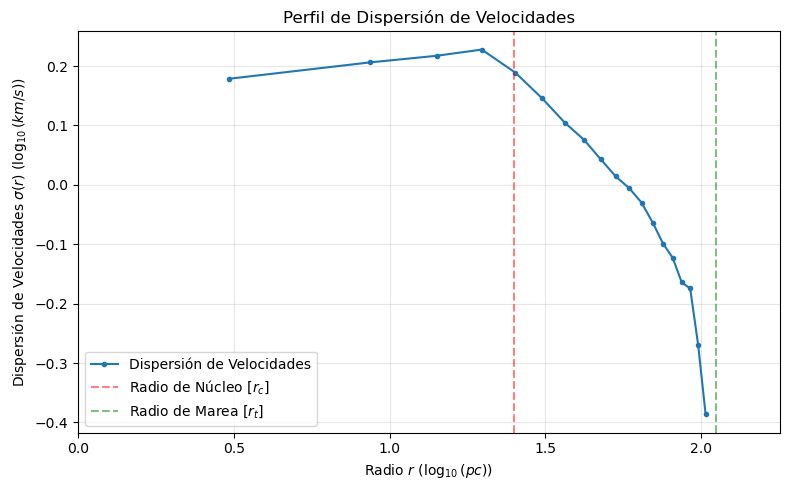

In [123]:
plt.figure(figsize=(8, 5))
plt.plot(np.log10(r_centers), np.log10(sigmas), '.-', label='Dispersión de Velocidades')
plt.axvline(np.log10(rc_fit), color='r', linestyle='--', alpha=0.5, label='Radio de Núcleo [$r_c$]')
plt.axvline(np.log10(rt_fit), color='g', linestyle='--', alpha=0.5, label='Radio de Marea [$r_t$]')

plt.title('Perfil de Dispersión de Velocidades')
plt.xlabel('Radio $r$ ($\log_{10}(pc)$)')
plt.ylabel('Dispersión de Velocidades $\sigma(r)$ ($\log_{10}(km/s)$)')
plt.xlim(0, np.log10(rt_fit) * 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

## Forma analítica

Se define las variables simbólicas y las constantes.

In [124]:
r, rp, x = sp.symbols('r rp x', positive=True, real=True)
rc, rt, k, G = sp.symbols('r_c r_t k G', positive=True, real=True)

Se define la función $w$ dependiente de una variable genérica.

In [125]:
def w_func(var):
    return sp.sqrt((1 + (var/rc)**2) / (1 + (rt/rc)**2))

In [126]:
w = w_func(r)

Se construye la función de densidad $\rho(r)$.

In [127]:
coeficiente = k / (sp.pi * rc * (1 + (rt/rc)**2)**sp.Rational(3, 2))
termino_w = (1 / w**2) * ((1/w) * sp.acos(w) - sp.sqrt(1 - w**2))

In [128]:
rho_r = coeficiente * termino_w

Se calcula la masa encerrada $M(< r)$ donde: $$M(<r) = \int_0^r 4 \pi x^2 \rho(x)\ \mathrm{d}x$$.

In [129]:
rho_x = rho_r.subs(r, x)
integrando_masa = 4 * sp.pi * x**2 * rho_x

In [130]:
M_r = sp.Integral(integrando_masa, (x, 0, r))

Se plantea la integral de la dispersión de velocidades $\sigma^2(r)$. (Se sustituye $r$ por $r'$ ($r_p$) para la integral exterior).

In [131]:
rho_rp = rho_r.subs(r, rp)
M_rp = M_r.subs(r, rp)

Se integra la ecuación de jeans.

In [132]:
integrando_sigma = rho_rp * G * M_rp / rp**2

Se plantea la integral desde $r$ hasta $r_t$.

In [133]:
integral_sigma = sp.Integral(integrando_sigma, (rp, r, rt))

Ecuación final de la dispersión de velocidades.

In [134]:
sigma_cuadrado = (1 / rho_r) * integral_sigma

In [135]:
sigma_cuadrado

pi*r_c*sqrt(1 + r_t**2/r_c**2)*(r**2/r_c**2 + 1)*Integral(G*k*(sqrt(1 + r_t**2/r_c**2)*acos(sqrt(1 + rp**2/r_c**2)/sqrt(1 + r_t**2/r_c**2))/sqrt(1 + rp**2/r_c**2) - sqrt(1 - (1 + rp**2/r_c**2)/(1 + r_t**2/r_c**2)))*Integral(4*k*x**2*(sqrt(1 + r_t**2/r_c**2)*acos(sqrt(1 + x**2/r_c**2)/sqrt(1 + r_t**2/r_c**2))/sqrt(1 + x**2/r_c**2) - sqrt(1 - (1 + x**2/r_c**2)/(1 + r_t**2/r_c**2)))/(r_c*sqrt(1 + r_t**2/r_c**2)*(1 + x**2/r_c**2)), (x, 0, rp))/(pi*r_c*rp**2*sqrt(1 + r_t**2/r_c**2)*(1 + rp**2/r_c**2)), (rp, r, r_t))/(k*(sqrt(1 + r_t**2/r_c**2)*acos(sqrt(r**2/r_c**2 + 1)/sqrt(1 + r_t**2/r_c**2))/sqrt(r**2/r_c**2 + 1) - sqrt(1 - (r**2/r_c**2 + 1)/(1 + r_t**2/r_c**2))))

## Cálculo numérico de la dispersión de velocidades

Se definen las funciones del modelo de King.

In [ ]:
def w_func_num(r, rc, rt):
    return np.sqrt((1 + (r/rc)**2) / (1 + (rt/rc)**2))

def rho_num(r, rc, rt, k):
    # Si r supera r_t, la densidad es cero
    if r >= rt:
        return 0.0
    
    w = w_func_num(r, rc, rt)

    coef = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)
    term = (1 / w**2) * ((1/w) * np.arccos(w) - np.sqrt(1 - w**2))

    return coef * term

Se define el integrando para calcular la masa encerrada.

In [137]:
def mass_integrand(x, rc, rt, k):
    return 4 * np.pi * x**2 * rho_num(x, rc, rt, k)

Se calcula la masa encerrada $M(<r)$ usando integración numérica.

In [138]:
def M_enclosed(r, rc, rt, k):
    if r == 0:
        return 0.0
    
    mass, _ = quad(mass_integrand, 0, r, args=(rc, rt, k))
    return mass

Se define el integrando de la ecuación de Jeans: $$\rho(r')\frac{G*M(<r')}{r'^2}$$

In [139]:
def jeans_integrand(rp, rc, rt, k):
    # Constante gravitacional G (pc * M_sun^-1 * (km/s)^2)
    G = 4.3009e-3 

    # Si rp es 0, se evita la división por cero
    if rp == 0:
        return 0.0
    
    rho_rp = rho_num(rp, rc, rt, k)
    if rho_rp == 0:
        return 0.0
    
    M_rp = M_enclosed(rp, rc, rt, k)
    return rho_rp * G * M_rp / rp**2

Se define la función de dispersión de velocidades $\sigma^2(r)$.

In [140]:
def sigma2(r, rc, rt, k):
    # Constante gravitacional G (pc * M_sun^-1 * (km/s)^2)
    G = 4.3009e-3 

    # Se evita calcular exactamente en r_t para evitar división por cero en rho(r_t)
    if r >= rt:
        return 0.0
    
    density = rho_num(r, rc, rt, k)
    if density == 0:
        return 0.0
    
    integral_jeans, _ = quad(jeans_integrand, r, rt, args=(rc, rt, k))
    return (1.0 / density) * integral_jeans

### Cálculo y graficación

Se crea u arreglo de radios desde casi 0 hasta casi $r_t$ (0.99 * $r_t$). Se evita $r=r_t$ exacto por la singularidad de dividir entre $\rho(r_t)=0$.

In [141]:
radii = np.linspace(0.01, rt_fit * 0.99, 100)

In [142]:
sigma_profile = [np.sqrt(sigma2(r, rc_fit, rt_fit, k_fit)) for r in radii]

/var/folders/s3/cfw1g3814k74v57_7sj327hw0000gn/T/ipykernel_4315/506995963.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(r_centers), np.log10(sigmas), '.-')


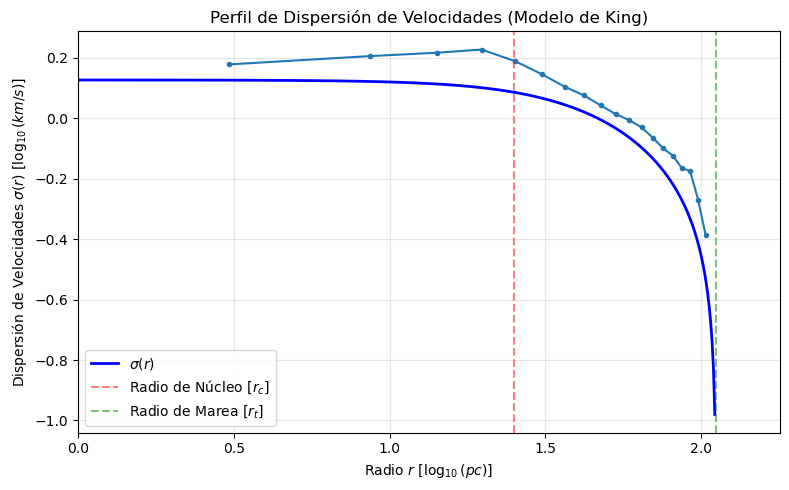

In [143]:
plt.figure(figsize=(8, 5))
plt.plot(np.log10(radii), np.log10(sigma_profile), '-', color='b', lw=2, label=r'$\sigma(r)$')
plt.plot(np.log10(r_centers), np.log10(sigmas), '.-')
plt.axvline(np.log10(rc_fit), color='r', linestyle='--', alpha=0.5, label='Radio de Núcleo [$r_c$]')
plt.axvline(np.log10(rt_fit), color='g', linestyle='--', alpha=0.5, label='Radio de Marea [$r_t$]')

plt.title('Perfil de Dispersión de Velocidades (Modelo de King)')
plt.xlabel('Radio $r$ [$\log_{10}(pc)$]')
plt.ylabel('Dispersión de Velocidades $\sigma(r)$ [$\log_{10}(km/s)$]')
plt.xlim(0, np.log10(rt_fit) * 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()